In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as grid_spec
import seaborn as sns
from imblearn.over_sampling import SMOTE


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score


from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Missing Data

In [3]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


Decision Tree to predict the missing BMI

In [4]:
DT_bmi_pipe = Pipeline( steps=[
                               ('scale',StandardScaler()),
                               ('lr',DecisionTreeRegressor(random_state=42))
                              ])
X = df[['age','gender','bmi']].copy()
X.gender = X.gender.replace({'Male':0,'Female':1,'Other':-1}).astype(np.uint8)

Missing = X[X.bmi.isna()]
X = X[~X.bmi.isna()]
Y = X.pop('bmi')
DT_bmi_pipe.fit(X,Y)
predicted_bmi = pd.Series(DT_bmi_pipe.predict(Missing[['age','gender']]),index=Missing.index)
df.loc[Missing.index,'bmi'] = predicted_bmi

In [5]:
print('Missing values: ',sum(df.isnull().sum()))

Missing values:  0


Tuổi cao có làm tăng nguy cơ đột quỵ không?

Giới tính có ảnh hưởng không?

BMI (chỉ số khối cơ thể) có vai trò gì?

In [6]:
variables = [variable for variable in df.columns if variable not in ['id','stroke']]

conts = ['age','avg_glucose_level','bmi']

Text(-20, 0.02, 'We see a positive skew in BMI and Glucose Level')

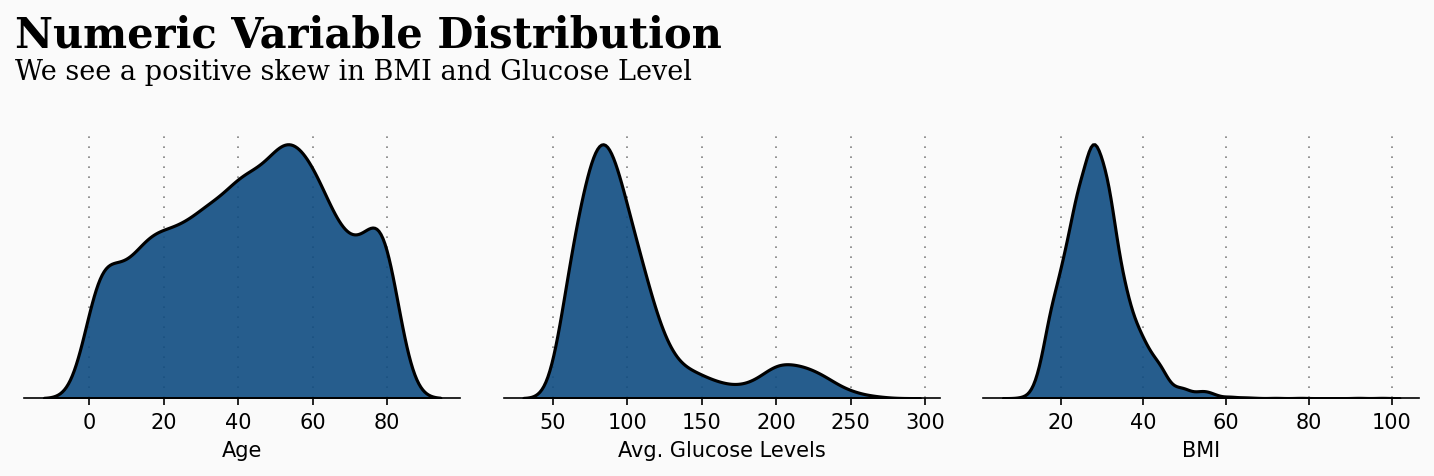

In [7]:
fig = plt.figure(figsize=(12, 12), dpi=150, facecolor='#fafafa')
gs = fig.add_gridspec(4, 3)
gs.update(wspace=0.1, hspace=0.4)

background_color = "#fafafa"

plot = 0
for row in range(0, 1):
    for col in range(0, 3):
        locals()["ax"+str(plot)] = fig.add_subplot(gs[row, col])
        locals()["ax"+str(plot)].set_facecolor(background_color)
        locals()["ax"+str(plot)].tick_params(axis='y', left=False)
        locals()["ax"+str(plot)].get_yaxis().set_visible(False)
        for s in ["top","right","left"]:
            locals()["ax"+str(plot)].spines[s].set_visible(False)
        plot += 1

plot = 0
for variable in conts:
        sns.kdeplot(df[variable] ,ax=locals()["ax"+str(plot)], color='#0f4c81', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        locals()["ax"+str(plot)].grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
        #locals()["ax"+str(plot)].set_xlabel(variable) removed this for aesthetics
        plot += 1

ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Levels')
ax2.set_xlabel('BMI')


ax0.text(-20, 0.022, 'Numeric Variable Distribution', fontsize=20, fontweight='bold', fontfamily='serif')
ax0.text(-20, 0.02, 'We see a positive skew in BMI and Glucose Level', fontsize=13, fontweight='light', fontfamily='serif')

Text(-20, 0.05, 'Age looks to be a prominent factor - this will likely be a salient feautre in our models')

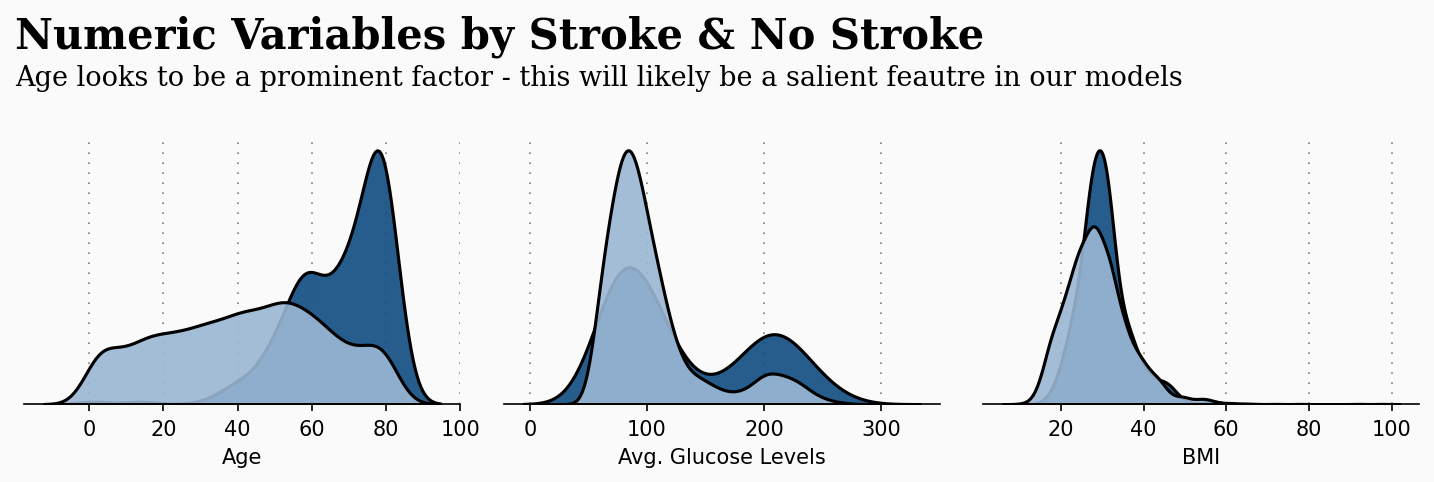

In [8]:
fig = plt.figure(figsize=(12, 12), dpi=150,facecolor=background_color)
gs = fig.add_gridspec(4, 3)
gs.update(wspace=0.1, hspace=0.4)


plot = 0
for row in range(0, 1):
    for col in range(0, 3):
        locals()["ax"+str(plot)] = fig.add_subplot(gs[row, col])
        locals()["ax"+str(plot)].set_facecolor(background_color)
        locals()["ax"+str(plot)].tick_params(axis='y', left=False)
        locals()["ax"+str(plot)].get_yaxis().set_visible(False)
        for s in ["top","right","left"]:
            locals()["ax"+str(plot)].spines[s].set_visible(False)
        plot += 1

plot = 0

s = df[df['stroke'] == 1]
ns = df[df['stroke'] == 0]

for feature in conts:
        sns.kdeplot(s[feature], ax=locals()["ax"+str(plot)], color='#0f4c81', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        sns.kdeplot(ns[feature],ax=locals()["ax"+str(plot)], color='#9bb7d4', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        locals()["ax"+str(plot)].grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
        #locals()["ax"+str(plot)].set_xlabel(feature)
        plot += 1

ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Levels')
ax2.set_xlabel('BMI')

ax0.text(-20, 0.056, 'Numeric Variables by Stroke & No Stroke', fontsize=20, fontweight='bold', fontfamily='serif')
ax0.text(-20, 0.05, 'Age looks to be a prominent factor - this will likely be a salient feautre in our models',
         fontsize=13, fontweight='light', fontfamily='serif')

Tuổi tác là một yếu tố lớn ảnh hưởng đến nguy cơ đột quỵ – tuổi càng cao thì nguy cơ mắc đột quỵ càng lớn.

Mặc dù không rõ ràng bằng, nhưng cũng có sự khác biệt trong mức đường huyết trung bình (Avg. Glucose Levels) và chỉ số BMI giữa những người bị và không bị đột quỵ.

In [9]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

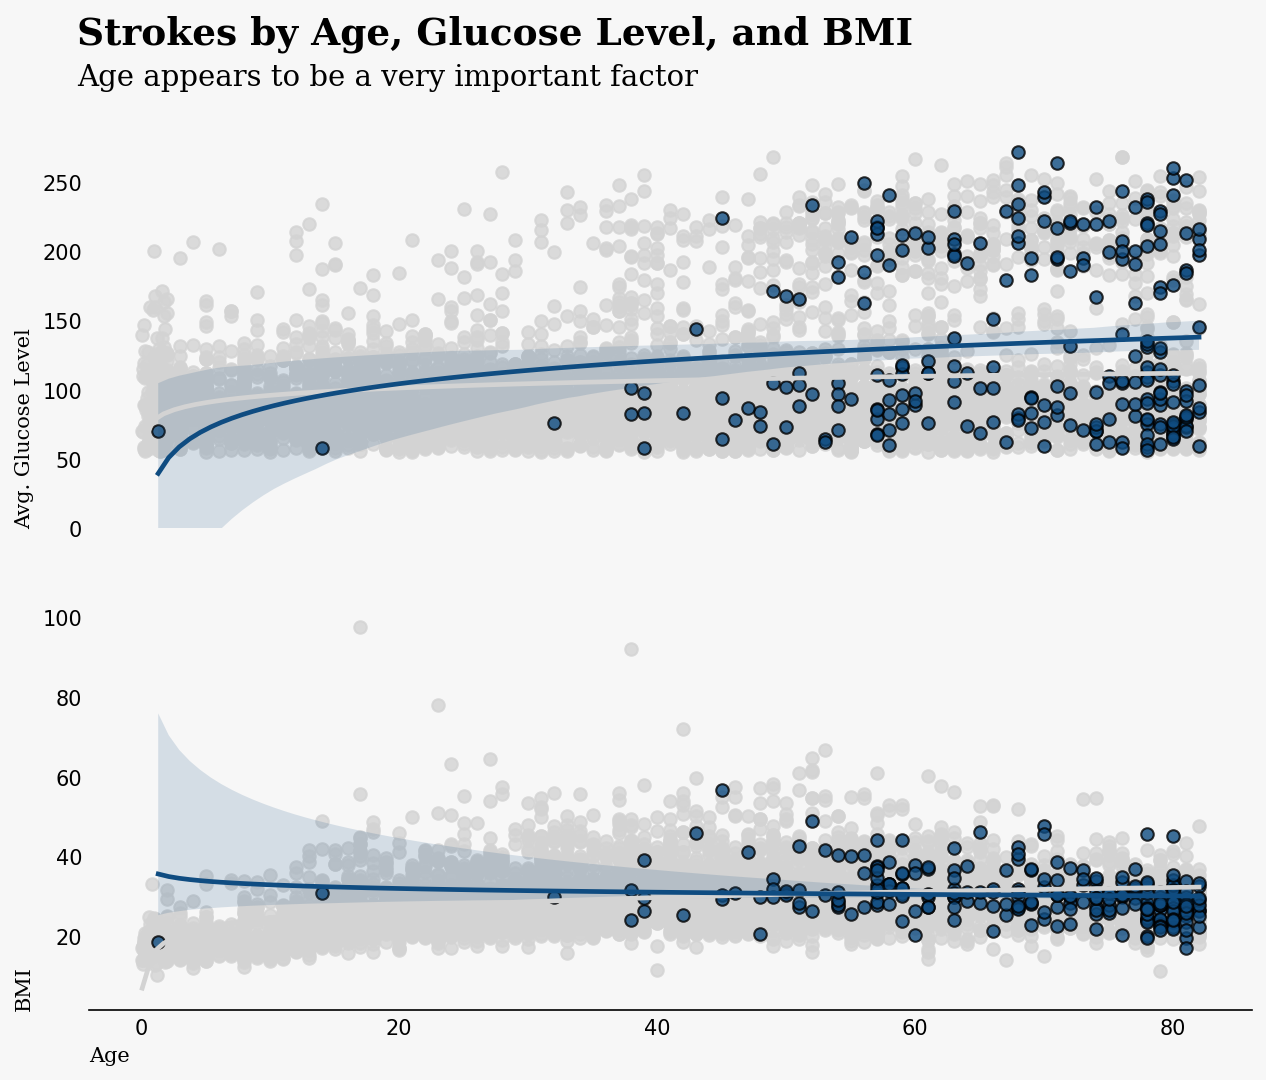

In [10]:
background_color = '#f7f7f7'
fig = plt.figure(figsize=(10, 16), dpi=150, facecolor=background_color)
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.5, hspace=0.2)

# Tạo 2 trục
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[1, 0:2])
ax0.set_facecolor(background_color)
ax1.set_facecolor(background_color)

# ===== 3. Biểu đồ Glucose theo tuổi =====
sns.regplot(x=no_str_only['age'], y=no_str_only['avg_glucose_level'],
            color='lightgray', logx=True, ax=ax0)

sns.regplot(x=str_only['age'], y=str_only['avg_glucose_level'],
            color='#0f4c81', logx=True,
            scatter_kws={'edgecolors': ['black'], 'linewidths': 1},
            ax=ax0)

ax0.set(ylim=(0, None))
ax0.set_xlabel(" ", fontsize=12, fontfamily='serif')
ax0.set_ylabel("Avg. Glucose Level", fontsize=10, fontfamily='serif', loc='bottom')
ax0.tick_params(axis='x', bottom=False)
ax0.get_xaxis().set_visible(False)

for s in ['top', 'left', 'bottom']:
    ax0.spines[s].set_visible(False)

# ===== 4. Biểu đồ BMI theo tuổi =====
sns.regplot(x=no_str_only['age'], y=no_str_only['bmi'],
            color='lightgray', logx=True, ax=ax1)

sns.regplot(x=str_only['age'], y=str_only['bmi'],
            color='#0f4c81',
            scatter_kws={'edgecolors': ['black'], 'linewidths': 1},
            logx=True,
            ax=ax1)

ax1.set_xlabel("Age", fontsize=10, fontfamily='serif', loc='left')
ax1.set_ylabel("BMI", fontsize=10, fontfamily='serif', loc='bottom')

for s in ['top', 'left', 'right']:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)

# ===== 5. Tiêu đề biểu đồ và ghi chú =====
ax0.text(-5, 350, 'Strokes by Age, Glucose Level, and BMI',
         fontsize=18, fontfamily='serif', fontweight='bold')
ax0.text(-5, 320, 'Age appears to be a very important factor',
         fontsize=14, fontfamily='serif')

# ===== 6. Tắt tick chiều dài =====
ax0.tick_params(axis='both', which='both', length=0)
ax1.tick_params(axis='both', which='both', length=0)

Tuổi tác là một yếu tố quan trọng, và cũng có mối quan hệ nhẹ với chỉ số BMI và mức đường huyết trung bình.

Có thể hiểu một cách trực quan rằng khi tuổi tăng lên, nguy cơ bị đột quỵ cũng tăng theo.

Text(-3, 0.047, 'As age increase, so too does risk of having a stroke')

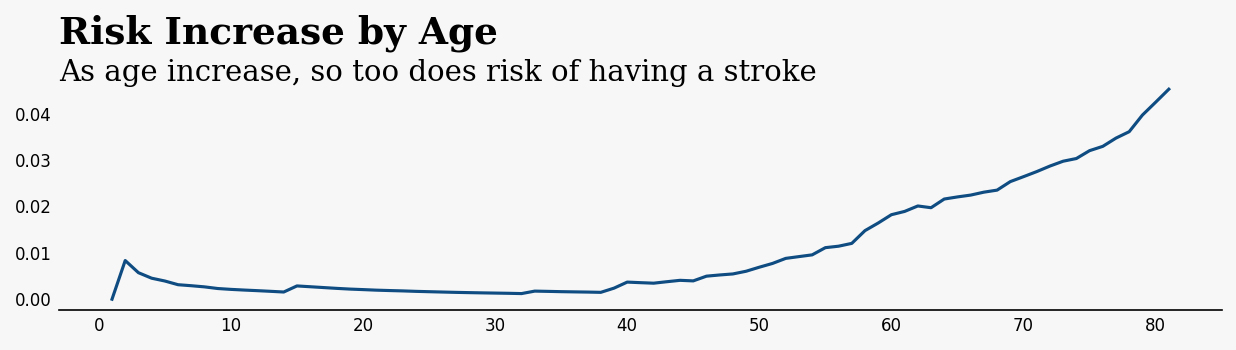

In [11]:
fig = plt.figure(figsize=(10, 5), dpi=150,facecolor=background_color)
gs = fig.add_gridspec(2, 1)
gs.update(wspace=0.11, hspace=0.5)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)


df['age'] = df['age'].astype(int)

rate = []
for i in range(df['age'].min(), df['age'].max()):
    rate.append(df[df['age'] < i]['stroke'].sum() / len(df[df['age'] < i]['stroke']))

sns.lineplot(data=rate,color='#0f4c81',ax=ax0)

for s in ["top","right","left"]:
    ax0.spines[s].set_visible(False)

ax0.tick_params(axis='both', which='major', labelsize=8)
ax0.tick_params(axis=u'both', which=u'both',length=0)

ax0.text(-3,0.055,'Risk Increase by Age',fontsize=18,fontfamily='serif',fontweight='bold')
ax0.text(-3,0.047,'As age increase, so too does risk of having a stroke',fontsize=14,fontfamily='serif')

Giá trị trên trục Y khá thấp. Nguyên nhân là vì tập dữ liệu của chúng ta bị mất cân bằng nghiêm trọng.

Chỉ có 249 trường hợp đột quỵ trong tổng số 5000 bản ghi — tức là khoảng 1 trên 20 người (tương đương ~5%).

Text(0.035, 0.65, 'This is around 1 in 20 people [249 out of 5000]')

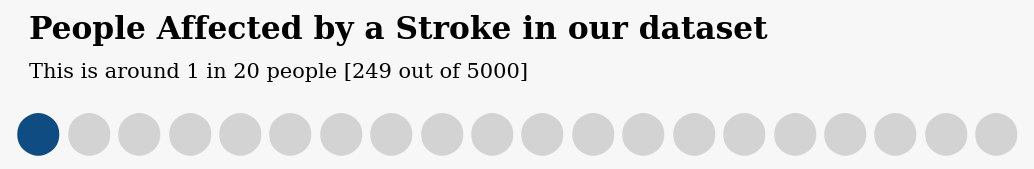

In [12]:
!pip install pywaffle
from pywaffle import Waffle

fig = plt.figure(figsize=(7, 2),dpi=150,facecolor=background_color,
    FigureClass=Waffle,
    rows=1,
    values=[1, 19],
    colors=['#0f4c81', "lightgray"],
    characters='⬤',
    font_size=20,vertical=True,
)

fig.text(0.035,0.78,'People Affected by a Stroke in our dataset',fontfamily='serif',fontsize=15,fontweight='bold')
fig.text(0.035,0.65,'This is around 1 in 20 people [249 out of 5000]',fontfamily='serif',fontsize=10)

In [13]:
# Drop single 'Other' gender
no_str_only = no_str_only[(no_str_only['gender'] != 'Other')]

## Tổng quan

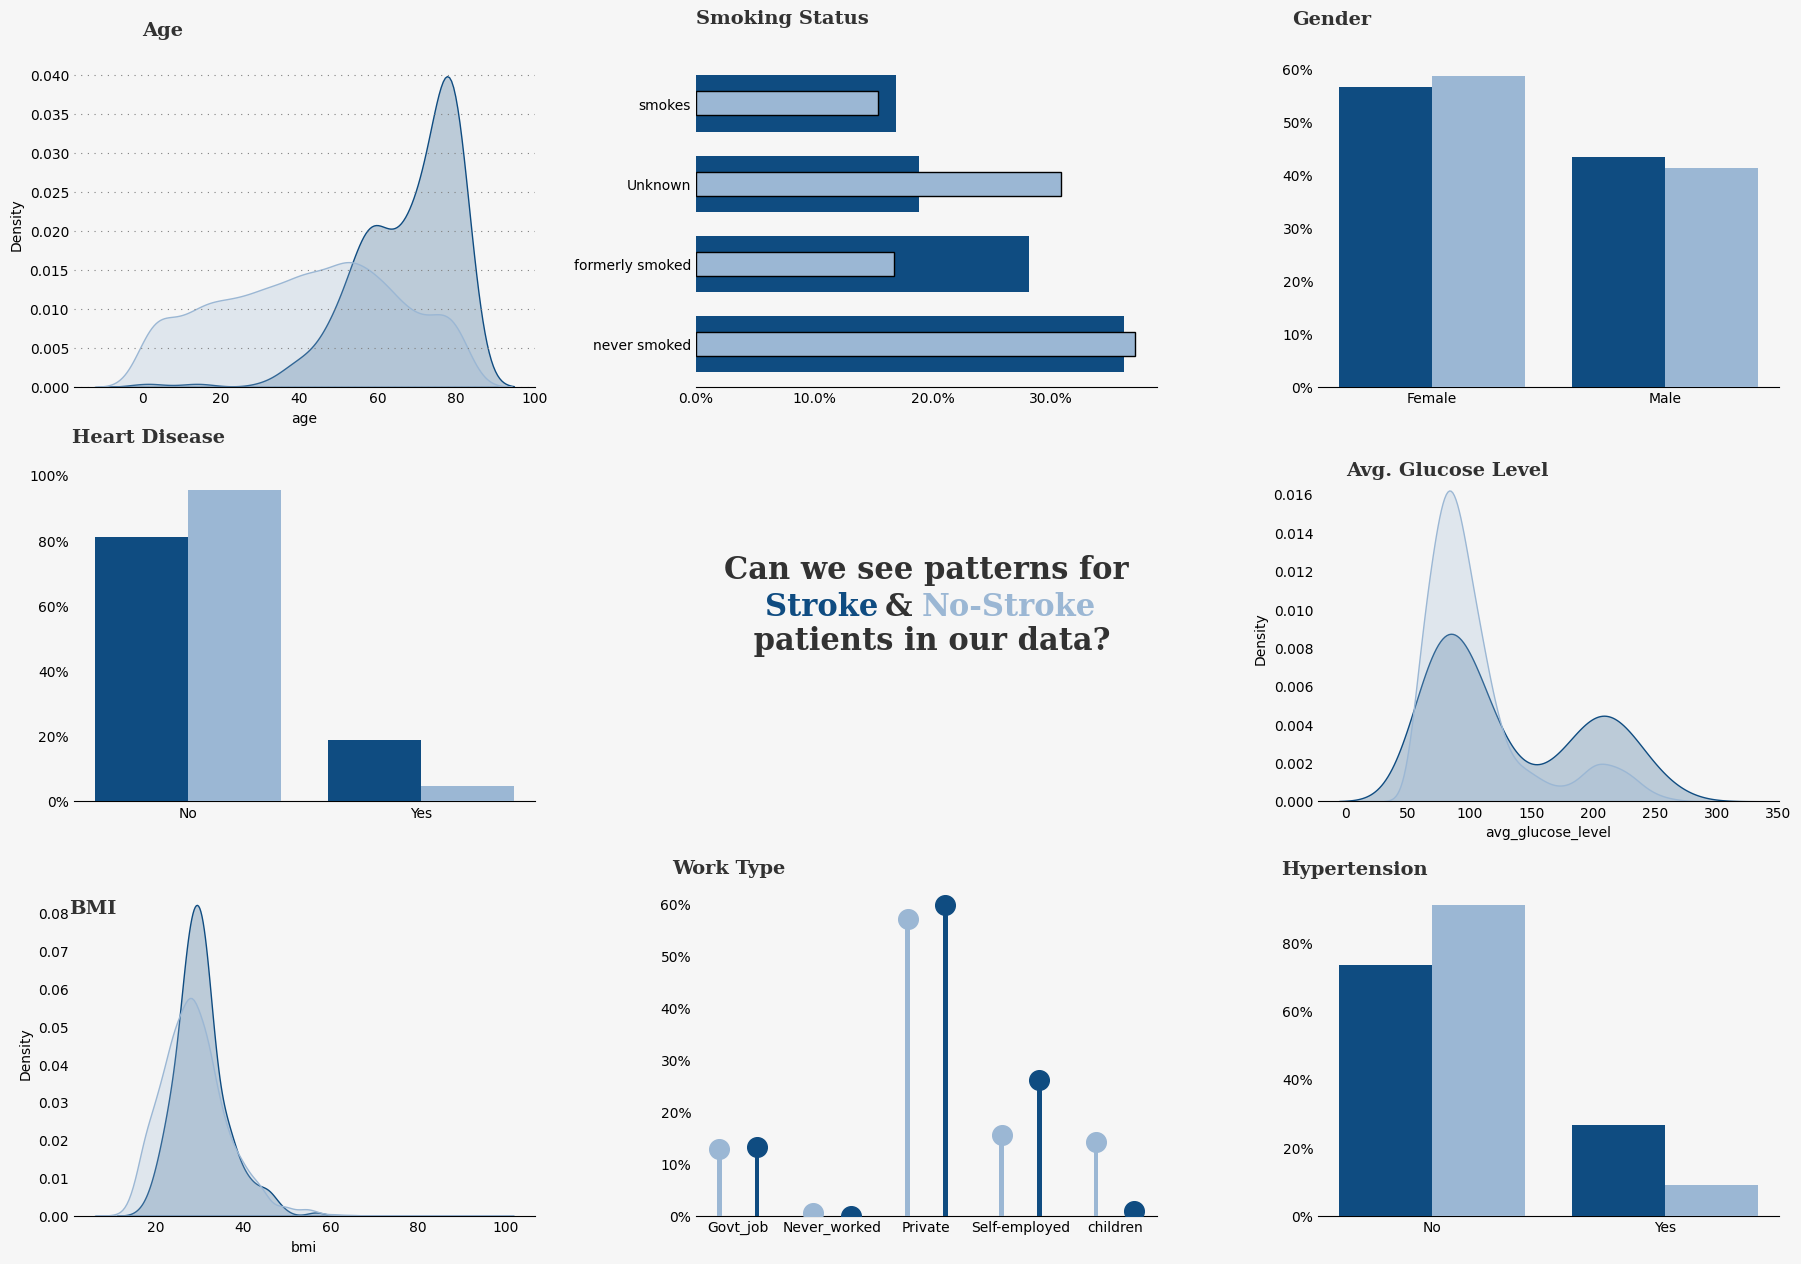

In [14]:
fig = plt.figure(figsize=(22, 15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.35, hspace=0.27)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(9)]
background_color = "#f6f6f6"
fig.patch.set_facecolor(background_color)

# === 1. Age Distribution ===
ax0 = axes[0]
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
sns.kdeplot(data=str_only, x="age", ax=ax0, color="#0f4c81", fill=True, linewidth=1, label="Stroke")
sns.kdeplot(data=no_str_only, x="age", ax=ax0, color="#9bb7d4", fill=True, linewidth=1, label="No Stroke")
ax0.text(0, 0.045, 'Age', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# === 2. Smoking Status ===
ax1 = axes[1]
p = str_only['smoking_status'].value_counts(normalize=True) * 100
n = no_str_only['smoking_status'].value_counts(normalize=True) * 100
ax1.text(0, 4, 'Smoking Status', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax1.barh(p.index, p.values, color="#0f4c81", zorder=3, height=0.7)
ax1.barh(n.index, n.values, color="#9bb7d4", zorder=3, height=0.3, edgecolor='black')
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
ax1.xaxis.set_major_locator(mtick.MultipleLocator(10))

# === 3. Gender ===
ax2 = axes[2]
p = str_only['gender'].value_counts(normalize=True) * 100
n = no_str_only['gender'].value_counts(normalize=True) * 100
x = np.arange(len(p))
ax2.text(-0.4, 68.5, 'Gender', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax2.bar(x, p.values, width=0.4, color="#0f4c81", zorder=3)
ax2.bar(x + 0.4, n.values, width=0.4, color="#9bb7d4", zorder=3)
ax2.set_xticks(x + 0.2)
ax2.set_xticklabels(p.index)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# === 4. Heart Disease ===
ax3 = axes[3]
p = str_only['heart_disease'].value_counts(normalize=True) * 100
n = no_str_only['heart_disease'].value_counts(normalize=True) * 100
x = np.arange(len(p))
ax3.text(-0.3, 110, 'Heart Disease', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax3.bar(x, p.values, width=0.4, color="#0f4c81", zorder=3)
ax3.bar(x + 0.4, n.values, width=0.4, color="#9bb7d4", zorder=3)
ax3.set_xticks(x + 0.2)
ax3.set_xticklabels(['No', 'Yes'])
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())

# === 5. Title panel ===
ax4 = axes[4]
ax4.axis('off')
ax4.text(0.5, 0.6, 'Can we see patterns for\n\n patients in our data?', ha='center', va='center',
         fontsize=22, fontweight='bold', fontfamily='serif', color="#323232")
ax4.text(0.15, 0.57, "Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#0f4c81')
ax4.text(0.41, 0.57, "&", fontweight="bold", fontfamily='serif', fontsize=22, color='#323232')
ax4.text(0.49, 0.57, "No-Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#9bb7d4')

# === 6. Avg Glucose ===
ax5 = axes[5]
sns.kdeplot(data=str_only, x="avg_glucose_level", ax=ax5, color="#0f4c81", fill=True, linewidth=1)
sns.kdeplot(data=no_str_only, x="avg_glucose_level", ax=ax5, color="#9bb7d4", fill=True, linewidth=1)
ax5.text(0, 0.017, 'Avg. Glucose Level', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# === 7. BMI ===
ax6 = axes[6]
sns.kdeplot(data=str_only, x="bmi", ax=ax6, color="#0f4c81", fill=True, linewidth=1)
sns.kdeplot(data=no_str_only, x="bmi", ax=ax6, color="#9bb7d4", fill=True, linewidth=1)
ax6.text(0, 0.08, 'BMI', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# === 8. Work Type ===
ax7 = axes[7]
p = str_only['work_type'].value_counts(normalize=True) * 100
n = no_str_only['work_type'].value_counts(normalize=True) * 100
idx = sorted(p.index.union(n.index))
x = np.arange(len(idx))
p = p.reindex(idx, fill_value=0)
n = n.reindex(idx, fill_value=0)
ax7.bar(x, n.values, width=0.05, color="#9bb7d4", zorder=3)
ax7.scatter(x, n.values, s=200, color="#9bb7d4", zorder=4)
ax7.bar(x + 0.4, p.values, width=0.05, color="#0f4c81", zorder=3)
ax7.scatter(x + 0.4, p.values, s=200, color="#0f4c81", zorder=4)
ax7.set_xticks(x + 0.2)
ax7.set_xticklabels(idx)
ax7.yaxis.set_major_formatter(mtick.PercentFormatter())
ax7.text(-0.5, 66, 'Work Type', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# === 9. Hypertension ===
ax8 = axes[8]
p = str_only['hypertension'].value_counts(normalize=True) * 100
n = no_str_only['hypertension'].value_counts(normalize=True) * 100
x = np.arange(len(p))
ax8.text(-0.45, 100, 'Hypertension', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
ax8.bar(x, p.values, width=0.4, color="#0f4c81", zorder=3)
ax8.bar(x + 0.4, n.values, width=0.4, color="#9bb7d4", zorder=3)
ax8.set_xticks(x + 0.2)
ax8.set_xticklabels(['No', 'Yes'])
ax8.yaxis.set_major_formatter(mtick.PercentFormatter())

# === Style & cleanup ===
for ax in axes:
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.set_facecolor(background_color)
    ax.tick_params(axis='both', length=0)

plt.tight_layout()

# Model preparation

In [15]:
# Encoding categorical values

df['gender'] = df['gender'].replace({'Male':0,'Female':1,'Other':-1}).astype(np.uint8)
df['Residence_type'] = df['Residence_type'].replace({'Rural':0,'Urban':1}).astype(np.uint8)
df['work_type'] = df['work_type'].replace({'Private':0,'Self-employed':1,'Govt_job':2,'children':-1,'Never_worked':-2}).astype(np.int8)

# Modelling
Liệu chúng ta có thể dự đoán một người có khả năng bị đột quỵ hay không?

Trước tiên, sẽ sử dụng SMOTE (Synthetic Minority Over-sampling Technique) để cân bằng lại tập dữ liệu.

Hiện tại, như đã đề cập ở trên, có rất nhiều ví dụ về người không bị đột quỵ, và điều này có thể ảnh hưởng tiêu cực đến mô hình vì nó sẽ học thiên lệch về lớp "không đột quỵ".

→ Giải pháp: Dùng SMOTE để tạo thêm dữ liệu giả lập hợp lý cho nhóm người bị đột quỵ, giúp cân bằng và cải thiện khả năng học của mô hình.


Với một tập dữ liệu mất cân bằng nghiêm trọng như thế này, một baseline hữu ích là vượt qua "Null Accuracy" – tức là độ chính xác khi luôn dự đoán nhãn phổ biến nhất.

Trong trường hợp của chúng ta, vì ta đang quan tâm đến việc phát hiện người bị đột quỵ (nhãn dương tính – stroke = 1), thì basline sẽ là:

👉 Xác suất xảy ra đột quỵ = 249 / (249 + 4861) = 0.048

Nói cách khác, nếu ta luôn dự đoán "không bị đột quỵ", thì ta đã đúng ~95% thời gian, nhưng sai toàn bộ với nhóm cần quan tâm nhất.

➡️ Vì vậy, một mục tiêu tốt cần vượt qua là đạt recall (độ bao phủ) > 5% cho các bệnh nhân bị đột quỵ.

In [16]:
# Inverse of Null Accuracy
print('Inverse of Null Accuracy: ',249/(249+4861))
print('Null Accuracy: ',4861/(4861+249))

Inverse of Null Accuracy:  0.0487279843444227
Null Accuracy:  0.9512720156555773


In [17]:
X  = df[['gender','age','hypertension','heart_disease','work_type','avg_glucose_level','bmi']]
y = df['stroke']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [18]:
X_test.head(10)

,gender,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi
4688,0,31,0,0,1,64.85,23.000000
4478,0,40,0,0,1,65.29,28.300000
3849,1,8,0,0,-1,74.42,22.500000
4355,1,79,1,0,1,76.64,19.500000
3826,1,75,0,0,2,94.77,27.200000
3951,1,79,1,0,1,92.43,27.934545
3396,1,56,1,0,0,97.37,34.100000
465,0,69,0,0,0,101.52,26.800000
410,0,7,0,0,1,64.06,18.900000
1632,1,1,0,0,-1,55.51,18.500000


In [19]:
# Our data is biased, we can fix this with SMOTE

oversample = SMOTE()
X_train_resh, y_train_resh = oversample.fit_resample(X_train, y_train.ravel())

# Model
Xây dựng các mô hình Random Forest, SVM và Logistic Regression.

Sử dụng cross-validation 10 lần (10-fold CV) để đánh giá hiệu suất mô hình.

In [20]:
# Models

# Scale our data in pipeline, then split

rf_pipeline = Pipeline(steps = [('scale',StandardScaler()),('RF',RandomForestClassifier(random_state=42))])
svm_pipeline = Pipeline(steps = [('scale',StandardScaler()),('SVM',SVC(random_state=42))])
logreg_pipeline = Pipeline(steps = [('scale',StandardScaler()),('LR',LogisticRegression(random_state=42))])

In [21]:
rf_cv = cross_val_score(rf_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1')
svm_cv = cross_val_score(svm_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1')
logreg_cv = cross_val_score(logreg_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1')

In [22]:
print('Mean f1 scores:')
print('Random Forest mean :',cross_val_score(rf_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1').mean())
print('SVM mean :',cross_val_score(svm_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1').mean())
print('Logistic Regression mean :',cross_val_score(logreg_pipeline,X_train_resh,y_train_resh,cv=10,scoring='f1').mean())

Mean f1 scores:
Random Forest mean : 0.9347748463566022
SVM mean : 0.8449552899590547
Logistic Regression mean : 0.7986056453760468


## Random Forest cho kết quả tốt nhất
Áp dụng mô hình lên dữ liệu âm (negative) chưa từng thấy.

In [23]:
rf_pipeline.fit(X_train_resh,y_train_resh)
svm_pipeline.fit(X_train_resh,y_train_resh)
logreg_pipeline.fit(X_train_resh,y_train_resh)

rf_pred = rf_pipeline.predict(X_test)
svm_pred = svm_pipeline.predict(X_test)
logreg_pred = logreg_pipeline.predict(X_test)

rf_cm = confusion_matrix(y_test,rf_pred )
svm_cm = confusion_matrix(y_test,svm_pred)
logreg_cm = confusion_matrix(y_test,logreg_pred )

rf_f1 = f1_score(y_test,rf_pred)
svm_f1 = f1_score(y_test,svm_pred)
logreg_f1 = f1_score(y_test,logreg_pred)

In [24]:
print('Mean f1 scores:')

print('RF mean :',rf_f1)
print('SVM mean :',svm_f1)
print('LR mean :',logreg_f1)

Mean f1 scores:
RF mean : 0.20689655172413793
SVM mean : 0.21782178217821782
LR mean : 0.25054945054945055


              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1444
           1       0.17      0.27      0.21        89

    accuracy                           0.88      1533
   macro avg       0.56      0.59      0.57      1533
weighted avg       0.91      0.88      0.89      1533

Accuracy Score: 0.8799739073711677


Text(0.5, 1.0, 'Confusion Matrix')

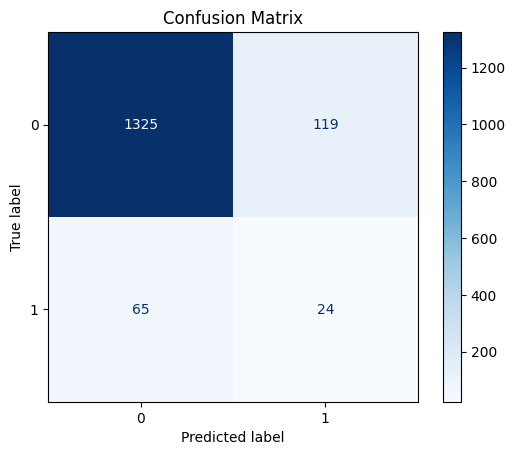

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

# In classification report và accuracy
print(classification_report(y_test, rf_pred))
print("Accuracy Score:", accuracy_score(y_test, rf_pred))

# Vẽ confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap='Blues')
plt.title("Confusion Matrix")

## Độ chính xác tốt, nhưng recall thấp

In [27]:
rfc = RandomForestClassifier()

In [28]:
rfc = RandomForestClassifier(max_features=2,n_estimators=100,bootstrap=True)

rfc.fit(X_train_resh,y_train_resh)

rfc_tuned_pred = rfc.predict(X_test)

In [29]:
print(classification_report(y_test,rfc_tuned_pred))

print('Accuracy Score: ',accuracy_score(y_test,rfc_tuned_pred))
print('F1 Score: ',f1_score(y_test,rfc_tuned_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1444
           1       0.18      0.29      0.23        89

    accuracy                           0.88      1533
   macro avg       0.57      0.61      0.58      1533
weighted avg       0.91      0.88      0.90      1533

Accuracy Score:  0.883235485975212
F1 Score:  0.22510822510822512


### Logistic Regression đã đạt F1-score cao nhất ở trên nên ta sẽ tinh chỉnh tham số của nó.

In [31]:
logreg_pipeline = Pipeline(steps = [('scale', StandardScaler()),
 ('LR', LogisticRegression(C=0.1,penalty='l2',random_state=42))])

logreg_pipeline.fit(X_train_resh,y_train_resh)

logreg_tuned_pred   = logreg_pipeline.predict(X_test)

In [32]:
print(classification_report(y_test,logreg_tuned_pred))

print('Accuracy Score: ',accuracy_score(y_test,logreg_tuned_pred))
print('F1 Score: ',f1_score(y_test,logreg_tuned_pred))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      1444
           1       0.16      0.65      0.25        89

    accuracy                           0.78      1533
   macro avg       0.57      0.72      0.56      1533
weighted avg       0.93      0.78      0.83      1533

Accuracy Score:  0.7788649706457925
F1 Score:  0.2549450549450549


Việc tinh chỉnh siêu tham số (hyper-parameter tuning) đã giúp cải thiện mô hình Logistic Regression.
Điểm recall (tỷ lệ nhận diện đúng các trường hợp bị đột quỵ) đã tốt hơn nhiều so với mô hình Random Forest – mặc dù độ chính xác tổng thể (accuracy) lại giảm đi."

Tuy nhiên, chúng ta có thể điều chỉnh ngưỡng (threshold) mà mô hình sử dụng để phân loại giữa đột quỵ và không đột quỵ.

## Tối ưu hóa SVM

In [35]:
svm_pipeline = Pipeline(steps = [('scale',StandardScaler()),
 ('SVM',SVC(C=1000,gamma=0.01,kernel='rbf',random_state=42))])

svm_pipeline.fit(X_train_resh,y_train_resh)

svm_tuned_pred   = svm_pipeline.predict(X_test)

In [36]:
print(classification_report(y_test,svm_tuned_pred))

print('Accuracy Score: ',accuracy_score(y_test,svm_tuned_pred))
print('F1 Score: ',f1_score(y_test,svm_tuned_pred))

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      1444
           1       0.14      0.54      0.23        89

    accuracy                           0.79      1533
   macro avg       0.55      0.67      0.55      1533
weighted avg       0.92      0.79      0.84      1533

Accuracy Score:  0.7853881278538812
F1 Score:  0.22588235294117648


In [54]:
from sklearn.preprocessing import binarize
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import numpy as np

for i in range(4, 9):
    threshold = i / 10

    # Dự đoán xác suất
    y_pred_prob = logreg_pipeline.predict_proba(X_test)[:, 1].reshape(-1, 1)

    # Phân ngưỡng
    y_pred_label = binarize(y_pred_prob, threshold=threshold)
    y_pred_label = y_pred_label.flatten()

    # Ma trận nhầm lẫn
    cm = confusion_matrix(y_test, y_pred_label)

    # Tính toán các chỉ số
    tp = cm[1, 1]
    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]

    accuracy = accuracy_score(y_test, y_pred_label)
    f1 = f1_score(y_test, y_pred_label)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    correct_preds = tp + tn

    # In kết quả
    print("=" * 50)
    print(f"🔹 Threshold = {threshold}")
    print(f"📊 Confusion Matrix:\n{cm}")
    print(f"✅ Correct Predictions: {correct_preds}")
    print(f"❌ False Positives (Type I Error): {fp}")
    print(f"❌ False Negatives (Type II Error): {fn}")
    print(f"📈 Accuracy: {accuracy:.4f}")
    print(f"🎯 F1 Score: {f1:.4f}")
    print(f"💓 Sensitivity (Recall): {sensitivity:.4f}")
    print(f"🛡️ Specificity: {specificity:.4f}")


🔹 Threshold = 0.4
📊 Confusion Matrix:
[[1040  404]
 [  26   63]]
✅ Correct Predictions: 1103
❌ False Positives (Type I Error): 404
❌ False Negatives (Type II Error): 26
📈 Accuracy: 0.7195
🎯 F1 Score: 0.2266
💓 Sensitivity (Recall): 0.7079
🛡️ Specificity: 0.7202
🔹 Threshold = 0.5
📊 Confusion Matrix:
[[1136  308]
 [  31   58]]
✅ Correct Predictions: 1194
❌ False Positives (Type I Error): 308
❌ False Negatives (Type II Error): 31
📈 Accuracy: 0.7789
🎯 F1 Score: 0.2549
💓 Sensitivity (Recall): 0.6517
🛡️ Specificity: 0.7867
🔹 Threshold = 0.6
📊 Confusion Matrix:
[[1212  232]
 [  40   49]]
✅ Correct Predictions: 1261
❌ False Positives (Type I Error): 232
❌ False Negatives (Type II Error): 40
📈 Accuracy: 0.8226
🎯 F1 Score: 0.2649
💓 Sensitivity (Recall): 0.5506
🛡️ Specificity: 0.8393
🔹 Threshold = 0.7
📊 Confusion Matrix:
[[1304  140]
 [  54   35]]
✅ Correct Predictions: 1339
❌ False Positives (Type I Error): 140
❌ False Negatives (Type II Error): 54
📈 Accuracy: 0.8735
🎯 F1 Score: 0.2652
💓 Sensitiv

Bằng cách điều chỉnh ngưỡng (threshold), ta có thể phát hiện thêm nhiều ca đột quỵ hơn.

Tuy nhiên, cần thận trọng với cách tiếp cận này. Ta có thể dễ dàng thay đổi ngưỡng sao cho mọi bệnh nhân đều bị dự đoán là có đột quỵ – để không bỏ sót bất kỳ ca nào – nhưng điều này lại không mang lại lợi ích thực sự.

Cái khó là tìm được sự cân bằng giữa 'dự đoán đúng' (hits) và 'dự đoán sai' (misses).

F1-score là một điểm khởi đầu khá tốt, vì nó là trung bình có trọng số của nhiều chỉ số đánh giá (precision và recall).

Dưới đây là một biểu đồ minh họa cho điều đó.

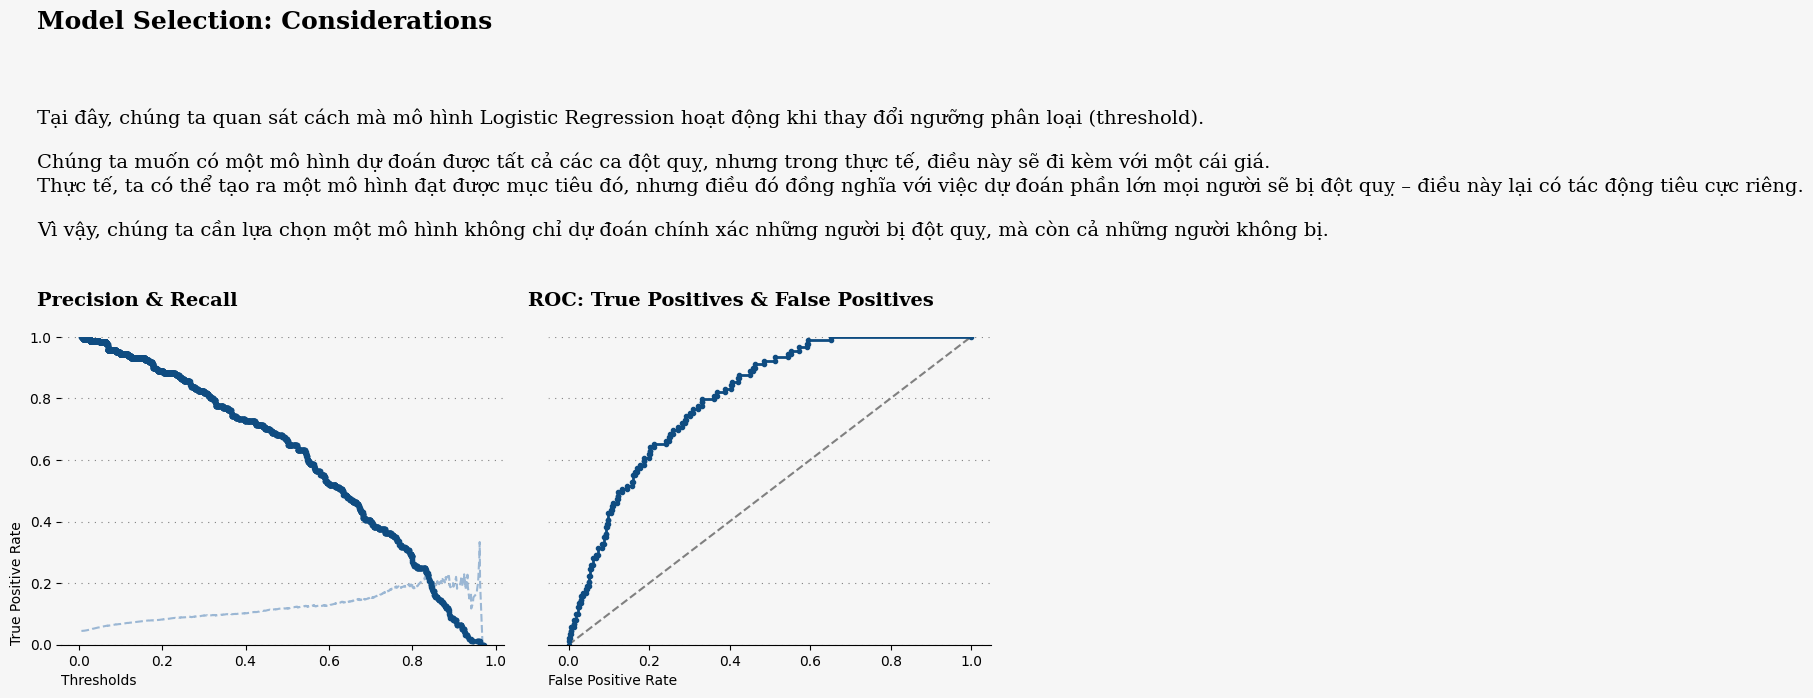

In [34]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve

ns_probs = [0 for _ in range(len(y_test))]
lr_probs = logreg_pipeline.predict_proba(X_test)
lr_probs = lr_probs[:, 1]
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

y_scores = logreg_pipeline.predict_proba(X_train)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

# Plots

fig = plt.figure(figsize=(12,4))
gs = fig.add_gridspec(1,2, wspace=0.1,hspace=0)
ax = gs.subplots()

background_color = "#f6f6f6"
fig.patch.set_facecolor(background_color) # figure background color
ax[0].set_facecolor(background_color)
ax[1].set_facecolor(background_color)

ax[0].grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax[1].grid(color='gray', linestyle=':', axis='y',  dashes=(1,5))



y_scores = logreg_pipeline.predict_proba(X_train)[:,1]


precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

ax[0].plot(thresholds, precisions[:-1], 'b--', label='Precision',color='#9bb7d4')
ax[0].plot(thresholds, recalls[:-1], '.', linewidth=1,label='Recall',color='#0f4c81')
ax[0].set_ylabel('True Positive Rate',loc='bottom')
ax[0].set_xlabel('Thresholds',loc='left')
#plt.legend(loc='center left')
ax[0].set_ylim([0,1])


# plot the roc curve for the model
ax[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Dummy Classifer',color='gray')
ax[1].plot(lr_fpr, lr_tpr, marker='.', linewidth=2,color='#0f4c81')
ax[1].set_xlabel('False Positive Rate',loc='left')
ax[1].set_ylabel('')
ax[1].set_ylim([0,1])

for s in ["top","right","left"]:
    ax[0].spines[s].set_visible(False)
    ax[1].spines[s].set_visible(False)


ax[0].text(-0.1,2,'Model Selection: Considerations',fontsize=18,fontfamily='serif',fontweight='bold')
ax[0].text(-0.1,1.26,
'''
Tại đây, chúng ta quan sát cách mà mô hình Logistic Regression hoạt động khi thay đổi ngưỡng phân loại (threshold).

Chúng ta muốn có một mô hình dự đoán được tất cả các ca đột quỵ, nhưng trong thực tế, điều này sẽ đi kèm với một cái giá.
Thực tế, ta có thể tạo ra một mô hình đạt được mục tiêu đó, nhưng điều đó đồng nghĩa với việc dự đoán phần lớn mọi người sẽ bị đột quỵ – điều này lại có tác động tiêu cực riêng.

Vì vậy, chúng ta cần lựa chọn một mô hình không chỉ dự đoán chính xác những người bị đột quỵ, mà còn cả những người không bị.
''',fontsize=14,fontfamily='serif')


ax[0].text(-0.1,1.1,'Precision & Recall',fontsize=14,fontfamily='serif',fontweight='bold')
ax[1].text(-0.1,1.1,'ROC: True Positives & False Positives',fontsize=14,fontfamily='serif',fontweight='bold')

ax[1].tick_params(axis='y', colors=background_color)

# Best Model
Random Forest sau khi được tinh chỉnh đã cho độ chính xác rất cao — khoảng 94%, nhưng chỉ có 2% recall (khả năng phát hiện đúng các ca đột quỵ).

Trong khi đó, mô hình ban đầu chỉ đạt 88% độ chính xác, nhưng recall lên tới 24% đối với bệnh nhân đột quỵ.

Theo quan điểm của tôi, một mô hình có recall cao (dù độ chính xác tổng thể thấp hơn) thì vẫn tốt hơn trong bối cảnh dự đoán đột quỵ, bởi vì việc phát hiện đúng những người có nguy cơ đột quỵ quan trọng hơn là khẳng định ai sẽ không bị.

In [37]:
# Make dataframes to plot

rf_df = pd.DataFrame(data=[f1_score(y_test,rf_pred),accuracy_score(y_test, rf_pred), recall_score(y_test, rf_pred),
                   precision_score(y_test, rf_pred), roc_auc_score(y_test, rf_pred)],
             columns=['Random Forest Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

svm_df = pd.DataFrame(data=[f1_score(y_test,svm_pred),accuracy_score(y_test, svm_pred), recall_score(y_test, svm_pred),
                   precision_score(y_test, svm_pred), roc_auc_score(y_test, svm_pred)],
             columns=['Support Vector Machine (SVM) Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

lr_df = pd.DataFrame(data=[f1_score(y_test,logreg_tuned_pred),accuracy_score(y_test, logreg_tuned_pred), recall_score(y_test, logreg_tuned_pred),
                   precision_score(y_test, logreg_tuned_pred), roc_auc_score(y_test, logreg_tuned_pred)],
             columns=['Tuned Logistic Regression Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

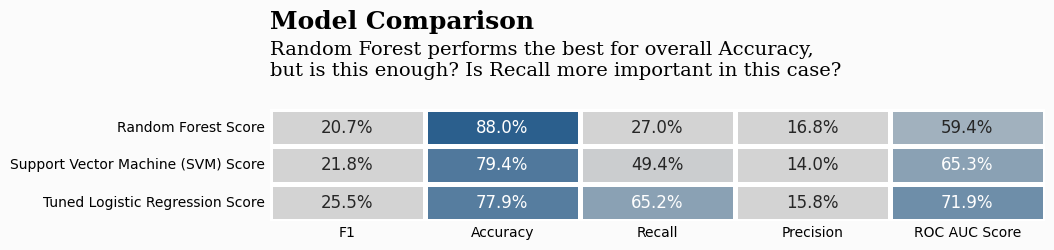

In [38]:
df_models = round(pd.concat([rf_df,svm_df,lr_df], axis=1),3)
import matplotlib
colors = ["lightgray","lightgray","#0f4c81"]
colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

background_color = "#fbfbfb"

fig = plt.figure(figsize=(10,8)) # create figure
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.1, hspace=0.5)
ax0 = fig.add_subplot(gs[0, :])

sns.heatmap(df_models.T, cmap=colormap,annot=True,fmt=".1%",vmin=0,vmax=0.95, linewidths=2.5,cbar=False,ax=ax0,annot_kws={"fontsize":12})
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color)

ax0.text(0,-2.15,'Model Comparison',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.text(0,-0.9,'Random Forest performs the best for overall Accuracy,\nbut is this enough? Is Recall more important in this case?',fontsize=14,fontfamily='serif')
ax0.tick_params(axis=u'both', which=u'both',length=0)

# Model by Model Confusion Matrix
Bây giờ chúng ta đã chọn được các mô hình phù hợp, ta có thể xem cách mỗi mô hình hoạt động trong việc dự đoán.

Một cách trực quan để thấy:

- Mô hình dự đoán đúng ở đâu (true positives & true negatives),

- Và sai ở đâu (false positives & false negatives).

Text(0, -0.2, 'A very similar performance to Logistic Regression.\nThe recall is slightly less though.')

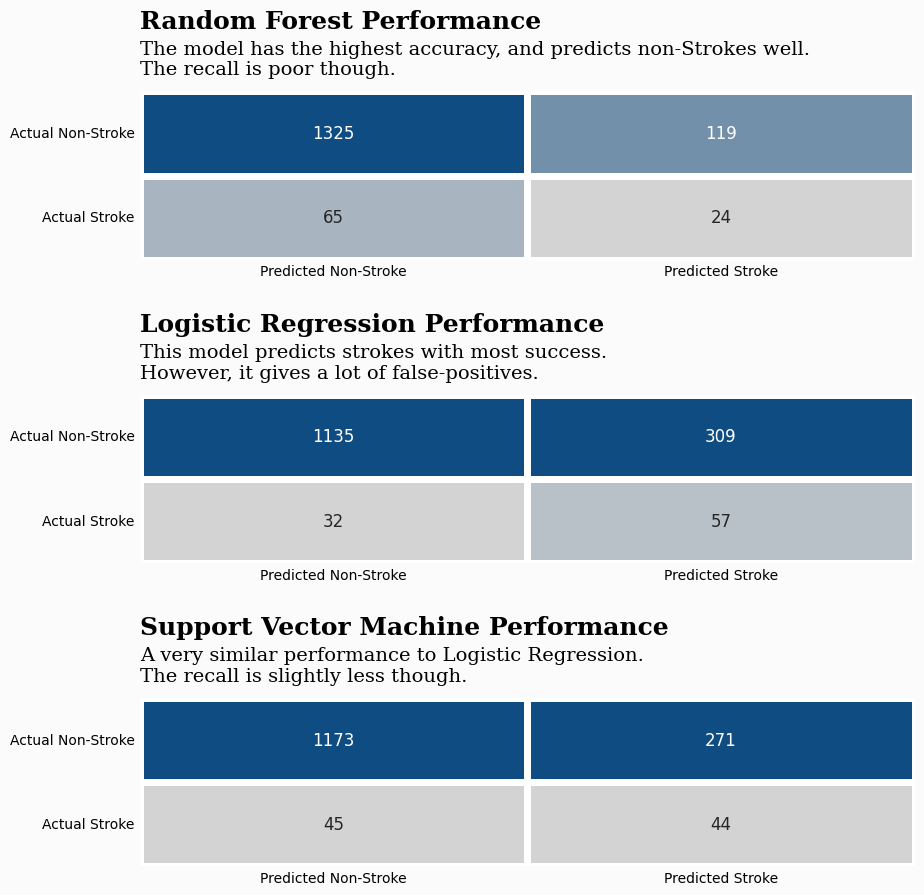

In [39]:
# Plotting our results

colors = ["lightgray","#0f4c81","#0f4c81","#0f4c81","#0f4c81","#0f4c81","#0f4c81","#0f4c81"]
colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)


background_color = "#fbfbfb"

fig = plt.figure(figsize=(10,14)) # create figure
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.1, hspace=0.8)
ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[2, :])
ax0.set_facecolor(background_color) # axes background color

# Overall
sns.heatmap(rf_cm, cmap=colormap,annot=True,fmt="d", linewidths=5,cbar=False,ax=ax0,
            yticklabels=['Actual Non-Stroke','Actual Stroke'],xticklabels=['Predicted Non-Stroke','Predicted Stroke'],annot_kws={"fontsize":12})

sns.heatmap(logreg_cm, cmap=colormap,annot=True,fmt="d", linewidths=5,cbar=False,ax=ax1,
            yticklabels=['Actual Non-Stroke','Actual Stroke'],xticklabels=['Predicted Non-Stroke','Predicted Stroke'],annot_kws={"fontsize":12})

sns.heatmap(svm_cm, cmap=colormap,annot=True,fmt="d", linewidths=5,cbar=False,ax=ax2,
            yticklabels=['Actual Non-Stroke','Actual Stroke'],xticklabels=['Predicted Non-Stroke','Predicted Stroke'],annot_kws={"fontsize":12})



ax0.tick_params(axis=u'both', which=u'both',length=0)
background_color = "#fbfbfb"
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color)
ax1.tick_params(axis=u'both', which=u'both',length=0)
ax1.set_facecolor(background_color)
ax2.tick_params(axis=u'both', which=u'both',length=0)
ax2.set_facecolor(background_color)

ax0.text(0,-0.75,'Random Forest Performance',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.text(0,-0.2,'The model has the highest accuracy, and predicts non-Strokes well.\nThe recall is poor though.',fontsize=14,fontfamily='serif')

ax1.text(0,-0.75,'Logistic Regression Performance',fontsize=18,fontweight='bold',fontfamily='serif')
ax1.text(0,-0.2,'This model predicts strokes with most success.\nHowever, it gives a lot of false-positives.',fontsize=14,fontfamily='serif')

ax2.text(0,-0.75,'Support Vector Machine Performance',fontsize=18,fontweight='bold',fontfamily='serif')
ax2.text(0,-0.2,'A very similar performance to Logistic Regression.\nThe recall is slightly less though.',fontsize=14,fontfamily='serif')

# Model Success
Tất cả các mô hình của chúng ta đều có độ chính xác (accuracy) khá cao, với mô hình Random Forest đã được tinh chỉnh đạt cao nhất khoảng 95%.

Tuy nhiên, khả năng dự đoán đúng các ca đột quỵ (recall) lại khá thấp ở tất cả các mô hình.
🎯 Cần xem xét kỹ lưỡng kết quả
Luôn cần đặt câu hỏi:

“Tại sao tôi cần dự đoán giá trị này?”

Trong trường hợp này, tôi cho rằng mục tiêu là để đưa ra lời khuyên y tế hoặc biện pháp điều trị phòng ngừa cho những người được dự đoán có khả năng bị đột quỵ.

→ Vì vậy, trong thực tế, tôi có xu hướng chọn mô hình có chỉ số recall cao nhất, tức là mô hình phát hiện đúng nhiều ca đột quỵ nhất, ngay cả khi độ chính xác tổng thể không cao bằng.

🏥 Mô hình có thể được xem là thành công
Điều đó có nghĩa là các chuyên gia y tế sẽ có thêm công cụ hỗ trợ ra quyết định, và chắc chắn tốt hơn là không có công cụ hỗ trợ nào.

Do mô hình Random Forest có độ chính xác cao nhất, tôi sẽ đi sâu vào phân tích mô hình này — cụ thể là:

Tầm quan trọng của các đặc trưng (Feature Importance)

Và giải thích mô hình bằng LIME

❗ Tuy nhiên...
Việc lựa chọn mô hình cuối cùng vẫn cần được cân nhắc, đặc biệt do sự chênh lệch rõ rệt về recall giữa các mô hình.

# Logistic Regression
Mô hình này có độ chính xác ở mức khá và có chỉ số recall tốt nhất. Đây là mô hình mang lại kết quả tổng thể tốt nhất.

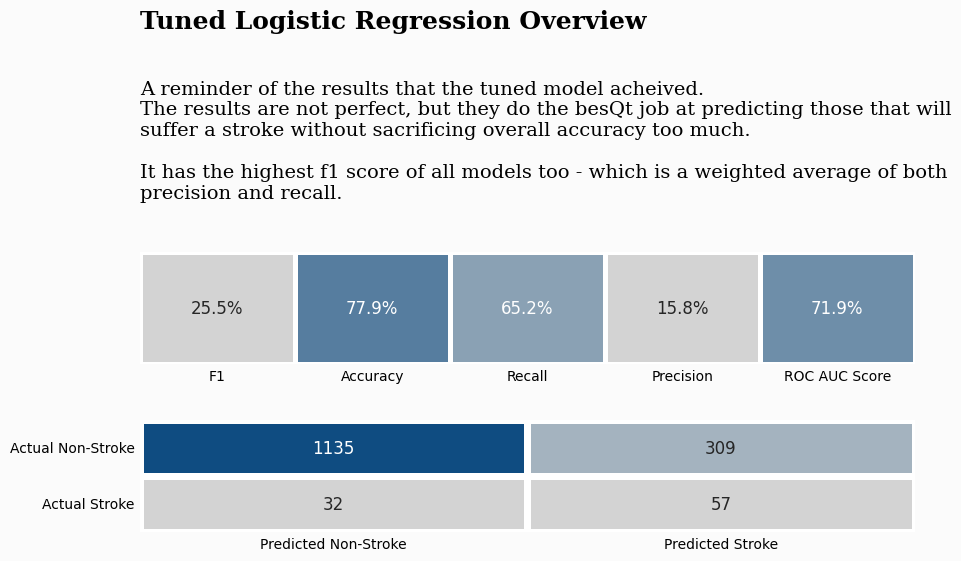

In [40]:
colors = ["lightgray","lightgray","#0f4c81"]
colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

background_color = "#fbfbfb"

fig = plt.figure(figsize=(10,8)) # create figure
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.1, hspace=0.5)
ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, :])

sns.heatmap(lr_df.T, cmap=colormap,annot=True,fmt=".1%",vmin=0,vmax=0.95,yticklabels='', linewidths=2.5,cbar=False,ax=ax0,annot_kws={"fontsize":12})
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color)
ax1.set_facecolor(background_color)

ax0.text(0,-2,'Tuned Logistic Regression Overview',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.text(0,-0.3,
'''
A reminder of the results that the tuned model acheived.
The results are not perfect, but they do the besQt job at predicting those that will
suffer a stroke without sacrificing overall accuracy too much.

It has the highest f1 score of all models too - which is a weighted average of both
precision and recall.
''',fontsize=14,fontfamily='serif')
ax0.tick_params(axis=u'both', which=u'both',length=0)



# Overall

sns.heatmap(logreg_cm, cmap=colormap,annot=True,fmt="d", linewidths=5,cbar=False,ax=ax1,
            yticklabels=['Actual Non-Stroke','Actual Stroke'],vmax=500,vmin=0,xticklabels=['Predicted Non-Stroke','Predicted Stroke'],annot_kws={"fontsize":12})
ax0.tick_params(axis=u'both', which=u'both',length=0)
ax1.tick_params(axis=u'both', which=u'both',length=0)
plt.show()

# Model Interpretation
Sử dụng một số công cụ hữu ích giúp khám phá “hộp đen” tưởng chừng của các thuật toán máy học.

# Bonus: : Khám phá sâu hơn về hiệu suất của Random Forest
Vì đây là mô hình có độ chính xác cao nhất (mặc dù không phải là chỉ số tốt nhất cho dự án này), nên sẽ bổ sung thêm một chút phân tích để chúng ta có thể hiểu rõ hơn cách Random Forest đưa ra các dự đoán của nó.

In [41]:
def rf_feat_importance(m, df):
    return pd.DataFrame({'Feature':df.columns, 'Importance':m.feature_importances_}).sort_values('Importance', ascending=False)


fi = rf_feat_importance(rf_pipeline['RF'], X)
fi[:10].style.background_gradient(cmap=colormap)

,Feature,Importance
1,age,0.412104
5,avg_glucose_level,0.240938
6,bmi,0.193669
4,work_type,0.073937
0,gender,0.050494
2,hypertension,0.014743
3,heart_disease,0.014115


3 đặc trưng quan trọng

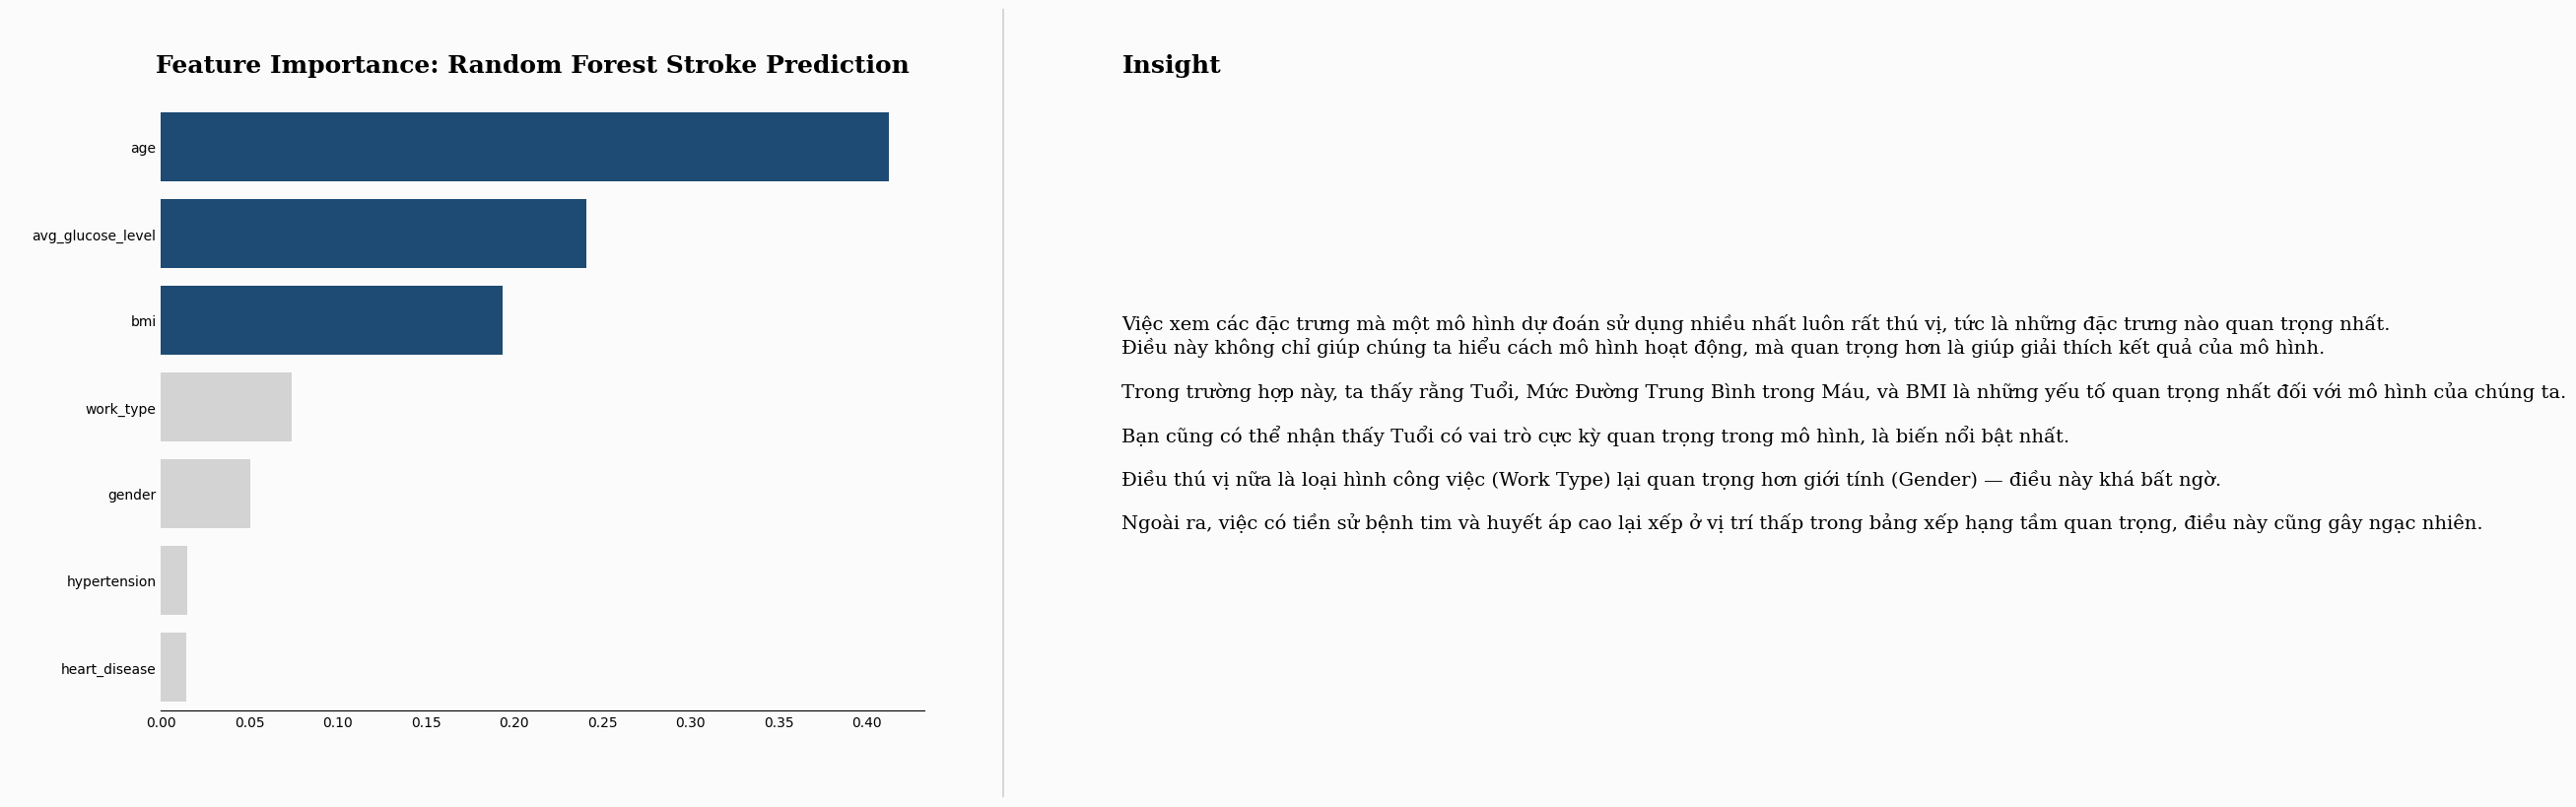

In [42]:
background_color = "#fbfbfb"

fig, ax = plt.subplots(1,1, figsize=(10, 8),facecolor=background_color)

color_map = ['lightgray' for _ in range(10)]
color_map[0] = color_map[1] = color_map[2] =  '#0f4c81' # color highlight

sns.barplot(data=fi,x='Importance',y='Feature',ax=ax,palette=color_map)
ax.set_facecolor(background_color)
for s in ['top', 'left', 'right']:
    ax.spines[s].set_visible(False)

fig.text(0.12,0.92,"Feature Importance: Random Forest Stroke Prediction", fontsize=18, fontweight='bold', fontfamily='serif')


plt.xlabel(" ", fontsize=12, fontweight='light', fontfamily='serif',loc='left',y=-1.5)
plt.ylabel(" ", fontsize=12, fontweight='light', fontfamily='serif')


fig.text(1.1, 0.92, 'Insight', fontsize=18, fontweight='bold', fontfamily='serif')

fig.text(1.1, 0.315, '''
Việc xem các đặc trưng mà một mô hình dự đoán sử dụng nhiều nhất luôn rất thú vị, tức là những đặc trưng nào quan trọng nhất.
Điều này không chỉ giúp chúng ta hiểu cách mô hình hoạt động, mà quan trọng hơn là giúp giải thích kết quả của mô hình.

Trong trường hợp này, ta thấy rằng Tuổi, Mức Đường Trung Bình trong Máu, và BMI là những yếu tố quan trọng nhất đối với mô hình của chúng ta.

Bạn cũng có thể nhận thấy Tuổi có vai trò cực kỳ quan trọng trong mô hình, là biến nổi bật nhất.

Điều thú vị nữa là loại hình công việc (Work Type) lại quan trọng hơn giới tính (Gender) — điều này khá bất ngờ.

Ngoài ra, việc có tiền sử bệnh tim và huyết áp cao lại xếp ở vị trí thấp trong bảng xếp hạng tầm quan trọng, điều này cũng gây ngạc nhiên.
'''
         , fontsize=14, fontweight='light', fontfamily='serif')

ax.tick_params(axis=u'both', which=u'both',length=0)


import matplotlib.lines as lines
l1 = lines.Line2D([0.98, 0.98], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])


plt.show()

# SHAP
Giá trị SHAP (SHapley Additive exPlanations) phân tích một dự đoán để thể hiện tác động của từng đặc trưng.

Nó giải thích ảnh hưởng của việc một đặc trưng có giá trị nhất định so với dự đoán nếu đặc trưng đó có giá trị cơ bản (ví dụ như bằng 0).

Trong trường hợp này, nên dùng SHAP cho mô hình Random Forest. SHAP có thể áp dụng cho bất kỳ loại mô hình nào, nhưng nhanh nhất và hiệu quả nhất khi dùng với các mô hình dựa trên cây.

Ngoài ra, chúng ta còn có thể thay đổi màu sắc trong các biểu đồ SHAP để dễ quan sát hơn.

In [43]:
!pip install shap
import shap

explainer = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(X_test)

print(f"shap_values.shape: {shap_values.shape}")

shap_values_for_plot = shap_values[:, :, 1]

print(f"shap_values_for_plot.shape: {shap_values_for_plot.shape}")
print(f"X_test.shape: {X_test.shape}")

shap_values.shape: (1533, 7, 2)
shap_values_for_plot.shape: (1533, 7)
X_test.shape: (1533, 7)


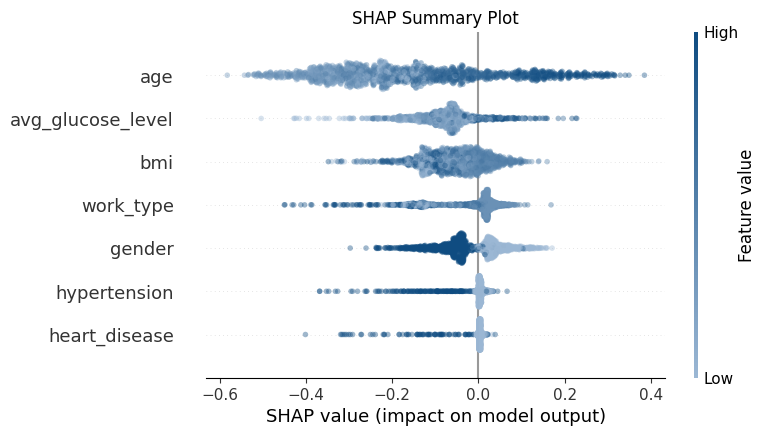

In [44]:
colors = ["#9bb7d4", "#0f4c81"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

shap.summary_plot(shap_values_for_plot, X_test, cmap=cmap, alpha=0.4, show=False)

plt.title("SHAP Summary Plot")
plt.xlabel("SHAP value (impact on model output)");

# SHAP explained
Biểu đồ trên thể hiện ảnh hưởng của từng điểm dữ liệu đến dự đoán của chúng ta.

Ví dụ, với biến Tuổi, điểm ở góc trên bên trái đã làm giảm giá trị dự đoán đi 0.6.

Màu sắc thể hiện đặc trưng đó có giá trị cao hay thấp đối với dòng dữ liệu đó. Vị trí ngang trên biểu đồ cho biết ảnh hưởng của giá trị đó làm tăng hay giảm dự đoán.

Chúng ta cũng có thể thấy mô hình Random Forest của mình có xu hướng dự đoán nhiều trường hợp không bị đột quỵ (no-strokes).
## SHAP dependence plots
Chúng ta có thể tập trung xem ảnh hưởng của từng biến thay đổi như thế nào khi giá trị biến đó thay đổi.

Ví dụ với biến Tuổi, khi tuổi tăng lên, giá trị SHAP cũng tăng theo — đẩy bệnh nhân gần hơn đến điều kiện 1 (đột quỵ).

Điều này cũng được thể hiện qua màu sắc — màu hồng/đỏ biểu thị những người đã bị đột quỵ.

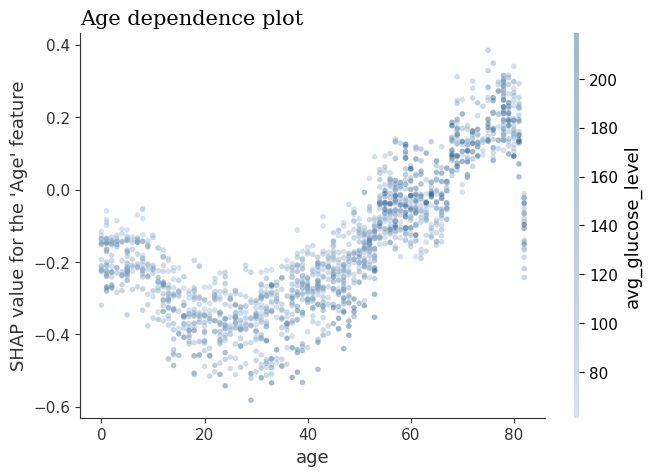

In [45]:
shap.dependence_plot('age', shap_values_for_plot, X_test, interaction_index="auto", cmap=cmap,alpha=0.4, show=False)

plt.title("Age dependence plot", loc='left', fontfamily='serif', fontsize=15)
plt.ylabel("SHAP value for the 'Age' feature");

Biểu đồ tương tự, nhưng lần này là với một biến thú vị hơn.

Ở đây, chúng ta thấy một ngưỡng rõ ràng mà sau đó các ca đột quỵ trở nên phổ biến hơn — khoảng BMI từ 30 trở lên.

Điều này cho thấy một mối liên hệ phi tuyến tính mà mô hình có thể đã học được:

- Với BMI thấp hơn 30, giá trị SHAP thường âm hoặc gần 0 — tức là ít ảnh hưởng đến khả năng dự đoán đột quỵ.

- Nhưng khi BMI vượt quá 30, giá trị SHAP tăng mạnh, kéo dự đoán gần hơn đến nhãn "1" (có đột quỵ).

Text(0, 0.5, "SHAP value for the 'BMI' feature")

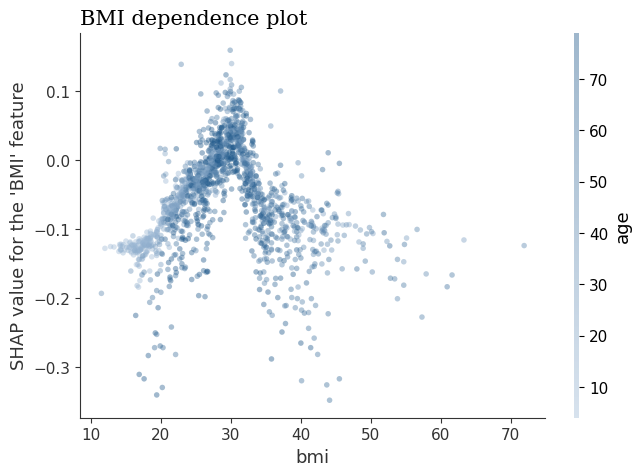

In [46]:
shap.dependence_plot('bmi', shap_values_for_plot, X_test, interaction_index="auto",cmap=cmap,alpha=0.4,show=False)

plt.title("BMI dependence plot",loc='left',fontfamily='serif',fontsize=15)
plt.ylabel("SHAP value for the 'BMI' feature")

# Logistic Regression with LIME
Tập trung phân tích một ví dụ cụ thể tại một thời điểm khi phân tích mô hình.

In [47]:
import lime
import lime.lime_tabular

# LIME has one explainer for all the models
explainer = lime.lime_tabular.LimeTabularExplainer(X.values, feature_names=X.columns.values.tolist(),
                                                  class_names=['stroke'], verbose=True, mode='classification')

In [48]:
# Choose the jth instance and use it to predict the results for that selection
j = 1
exp = explainer.explain_instance(X.values[j], logreg_pipeline.predict_proba, num_features=5)

Intercept 0.22374475210586686
Prediction_local [0.33778327]
Right: 0.48811112564468095


In [49]:
# Show the predictions
exp.show_in_notebook(show_table=True)

# ELI5 for feature explanation
Giúp giải thích mô hình máy học theo cách đơn giản nhất, gần như là "giải thích cho một đứa trẻ 5 tuổi hiểu".

In [50]:
!pip install eli5
import eli5

columns_ = ['gender', 'age', 'hypertension', 'heart_disease', 'work_type',
       'avg_glucose_level', 'bmi']

eli5.show_weights(logreg_pipeline.named_steps["LR"], feature_names=columns_)

Weight?,Feature
+1.910,age
+0.284,avg_glucose_level
-0.043,bmi
-0.142,<BIAS>
-0.218,hypertension
-0.297,heart_disease
-0.466,work_type
-0.484,gender


# Conclusion
Chúng ta bắt đầu bằng việc khám phá dữ liệu và nhanh chóng nhận ra rằng một số đặc trưng – chẳng hạn như tuổi (Age) – là những chỉ báo khá tốt để dự đoán khả năng đột quỵ.

Sau khi trực quan hóa dữ liệu một cách toàn diện, tôi đã thử nghiệm nhiều mô hình khác nhau:
✅ Random Forest,
✅ SVM,
✅ và Logistic Regression.

Tiếp theo, tôi tiến hành tinh chỉnh siêu tham số (hyperparameter tuning) cho tất cả các mô hình nhằm cải thiện hiệu suất dự đoán.

Mặc dù Random Forest đạt độ chính xác (accuracy) cao nhất, mô hình Logistic Regression sau khi tinh chỉnh lại có kết quả tốt nhất về recall và F1-score – vốn là những chỉ số quan trọng hơn trong bối cảnh dự đoán bệnh như đột quỵ, nơi mà sai sót loại II (bỏ sót ca bệnh) cần được hạn chế tối đa.

👉 Vì lý do đó, tôi đã chọn Logistic Regression được tinh chỉnh làm mô hình chính thức.

Tuy nhiên, tôi chưa dừng lại ở đó.
Để hiểu rõ hơn tại sao Random Forest lại đạt độ chính xác cao như vậy, tôi đã xem xét tầm quan trọng của các đặc trưng (feature importance) và giới thiệu công cụ SHAP – một cách tiếp cận mạnh mẽ giúp:

- Hiểu mô hình đưa ra quyết định như thế nào,

- Và nhận diện những điểm mà mô hình có thể sai lệch.

Cuối cùng, tôi áp dụng LIME và ELI5 lên mô hình Logistic Regression đã chọn để:

- Diễn giải rõ ràng cách các đặc trưng tác động đến dự đoán,

- Giúp mô hình trở nên minh bạch và giải thích được đối với các bên liên quan trong doanh nghiệp.

🔍 Tóm lại:
Đây là một quy trình mạnh mẽ, không chỉ tối ưu hiệu suất mô hình mà còn cung cấp khả năng giải thích toàn diện – một yếu tố then chốt trong các ứng dụng học máy thực tiễn, nơi sự minh bạch và niềm tin là cực kỳ quan trọng.